# Optical Model 

### The optical model has two inputs, the state variable which is explicit, and the geometry of the experiment which is implicit.

$$
A(x, geometry)
$$

The geometry is a function which simulates the rays propogating into and through the container and identifies which cells each ray crosses and how much of that ray is within each cell. This is later used to simulate the light intensity physics caused by lambert-beer attenuation, inverse law, and other phenomena.


## Part 1: defining the Geomerty function

The geometry function has several components,
- Initialize the rays and refract them through the mediums (air, perspex, fluid) to get the ray starting locations and angles at which they enter the container
- remove any rays which are outside our container 
- Parameterize each ray using a variable '$s$' to propogate them through the container, and compute the value 's' at which the ray leaves the container
- For each ray, compute every 's' value at which it intersects a cell boundary, and compute how much 's' (or conceptually 'ray') is within each cell ($\Delta s$)
- output a matrix where each row represents a ray and each element in that row defines a cell that this ray traverses and how much of that ray is in that cell (i,j, $\Delta s$)

```python
def geometry(grid, tank_width, tank_height):
    rays = stage1_ray_construction()
    rays = filter_rays_entering_container(rays, tank_width)
    rays = add_s_exit(rays, tank_width, tank_height)
    segments = compute_ray_segments(rays, grid)

    return {
        "segments": segments
    }




### Stage 1: Initialize rays and refraction (Snells Law)

In [7]:
import numpy as np

**Globally defined parameters** 

In [8]:
# laser fan parameters
NUMBER_OF_RAYS = 100 #total rays 
FAN_HALF_ANGLE_DEG = 45 
FAN_HALF_ANGLE = np.deg2rad(FAN_HALF_ANGLE_DEG) #half fan angle in radians

# refractive indicies 
N_air = 1.0003
N_perspex = 1.49
N_saltwater = 1.35

#distances of laser from container
Distance_air_perspex = 0.05    # meters
Distance_perspex_fluid = 0.005 # meters

Tank_width = 0.2         # meters
Tank_height = 0.4        # meters
Camera_view_height = 0.3 # meters

#assumed effective laser source x & z locations
laser_1_x = 0.05
laser2_x =0.15


#fluid entry boundary
z_entry = 0.0

# grid geometry (number of cells and cell width/height)
Number_of_columns = 64
Number_of_rows = 64

delta_x = Tank_width / Number_of_columns # individual cell width
delta_z = Tank_height / Number_of_rows   # individual cell height

grid = grid = {
    "dx": delta_x,
    "dz": delta_z,
    "nx": Number_of_columns,
    "nz": Number_of_rows
}

**Helper functions for stage 1**

In [9]:
def generate_fan_angles(n_rays, fan_half_angle):
    ''' Generates n_rays evenly spaced angles''' 
    if n_rays == 1:
        return np.array([0.0]) #if we only have 1 ray then we return a ray that is vertical to the laser source 
    return np.linspace(-fan_half_angle, fan_half_angle, n_rays)  #evenly spaced angles 

def snells_law(theta_in, n1, n2):
    ''' Applies snells:
            law n1 * sin(theta_in) = n2 * sin(theta_out)
        Angles are measured from the vertical'''
    
    argument = (n1/n2)* np.sin(theta_in)

    # Numerical safety: keeps the argument within the valid domain, safeguarding from floating point error
    argument = np.clip(argument, -1.0, 1.0)

    return np.arcsin(argument)

def filter_rays_entering_container(rays, tank_width):
    x_entry = rays[:, 2]
    valid_mask = (x_entry >= 0.0) & (x_entry <= tank_width)
    return rays[valid_mask]

def build_rays_for_one_laser(x_source, n_rays, laser_id, tank_width):
    '''builds all the entry rays for one laser source
    
    returns an array of shape (n_rays, 5), where each row is 
    [laser_id, ray_id, x_entry, z_entry, theta_fluid]'''

    # 1) initial fan angles in air
    theta_air = generate_fan_angles(n_rays, FAN_HALF_ANGLE)

    # 2) refract air -> perspec 
    theta_perspex = snells_law(theta_air, N_air, N_perspex)

    # 3) refract perspex ->  fluid
    theta_fluid = snells_law(theta_perspex, N_perspex, N_saltwater)

    # 4) slight change in x or z direction (later for straight line equation)
    dir_x = np.sin(theta_fluid)
    dir_z = np.cos(theta_fluid)

    # 5) Horizontal shift before entering fluid
    dx_air = Distance_air_perspex * np.tan(theta_air)
    dx_perspex = Distance_perspex_fluid * np.tan(theta_perspex)

    x_entry = x_source + dx_air + dx_perspex

    # 6) source-to-entry distance
    eps = 1e-6 # to stop cos(theta) being treated as zero for small values  and solution blowing up

    r_entry = (
        Distance_air_perspex / np.maximum(np.cos(theta_air), eps)
        + Distance_perspex_fluid / np.maximum(np.cos(theta_perspex), eps)
    )

    # 7) pack results
    ray_id = np.arange(n_rays) # makes an array of integars each representing a ray_id

    rays = np.column_stack([np.full(n_rays, laser_id), # an array of length n_rays of laser_id value
                             ray_id, # all the ray_id numbers 
                             x_entry, # all the x entry values
                             np.full(n_rays, z_entry), #an array of length n_rays of z_entry values
                             theta_fluid, # all the angles entering the fluid 
                             dir_x,
                             dir_z,
                             r_entry
                             ]) 
    
    rays = filter_rays_entering_container(rays, tank_width) #filters out any rays outside the container

    return rays


**Main function for Stage 1**

In [10]:
def stage1_ray_construction(tank_width):
    '''Based on the number-of-(total)-rays variable globally defined,
    this function builds all the refracted rays for both lasers and returns 
    their entry points and angle'''

    if NUMBER_OF_RAYS % 2 !=0:
        raise ValueError('Number of rays must be even so it can be split equally between the two lasers.')
    
    rays_per_laser = NUMBER_OF_RAYS // 2

    rays_laser1 = build_rays_for_one_laser(x_source=laser_1_x,
                                           n_rays=rays_per_laser,
                                           laser_id=0,
                                           tank_width=tank_width)
    
    rays_laser2 = build_rays_for_one_laser(x_source=laser2_x,
                                           n_rays=rays_per_laser,
                                           laser_id=1,
                                           tank_width=tank_width)
    
    all_rays = np.vstack([rays_laser1, rays_laser2])
    return all_rays # size=(number of rays, 8), row_entry = [laser_id, ray_id, x_entry, z_entry, theta_fluid, dir_x, dir_z, r_entry]

### Execution 

In [11]:
all_rays = stage1_ray_construction(Tank_width)
valid_rays = filter_rays_entering_container(all_rays, tank_width=0.2)

rays = valid_rays
print('shape of ray matrix:', rays.shape)
print('First 5 rows: \n', rays[:5])

shape of ray matrix: (98, 8)
First 5 rows: 
 [[ 0.00000000e+00  1.00000000e+00  5.22180290e-04  0.00000000e+00
  -5.31558768e-01 -5.06877642e-01  8.62018014e-01  7.41774896e-02]
 [ 0.00000000e+00  2.00000000e+00  3.56000418e-03  0.00000000e+00
  -5.11280617e-01 -4.89294498e-01  8.72118624e-01  7.21596769e-02]
 [ 0.00000000e+00  3.00000000e+00  6.43751253e-03  0.00000000e+00
  -4.90660505e-01 -4.71208570e-01  8.82021816e-01  7.03180832e-02]
 [ 0.00000000e+00  4.00000000e+00  9.17268531e-03  0.00000000e+00
  -4.69722036e-01 -4.52638444e-01  8.91694140e-01  6.86355367e-02]
 [ 0.00000000e+00  5.00000000e+00  1.17811456e-02  0.00000000e+00
  -4.48487600e-01 -4.33603201e-01  9.01103914e-01  6.70972661e-02]]


### Output Visualized

| laser_id | ray_k | $x_{\text{entry}}$ | $z_{\text{entry}}$ | $\theta_{\text{fluid}}$ | dir_x | dir_z | $r_{\text{entry}}$ |
|---------|------|------------------|------------------|----------------------|-------|-------|------------------|
| 1 | 1 | $x_1$ | $0$ | $\theta_1$ | $\sin(\theta_1)$ | $\cos(\theta_1)$ | $r_{\text{entry},1}$ |
| 1 | 2 | $x_2$ | $0$ | $\theta_2$ | $\sin(\theta_2)$ | $\cos(\theta_2)$ | $r_{\text{entry},2}$ |
| ... | ... | ... | ... | ... | ... | ... | ... |
| 2 | 1 | $x_1'$ | $0$ | $\theta_1'$ | $\sin(\theta_1')$ | $\cos(\theta_1')$ | $r'_{\text{entry},1}$ |
| 2 | 2 | $x_2'$ | $0$ | $\theta_2'$ | $\sin(\theta_2')$ | $\cos(\theta_2')$ | $r'_{\text{entry},2}$ |
| ... | ... | ... | ... | ... | ... | ... | ... |

### CHATGBT Sanity checker 

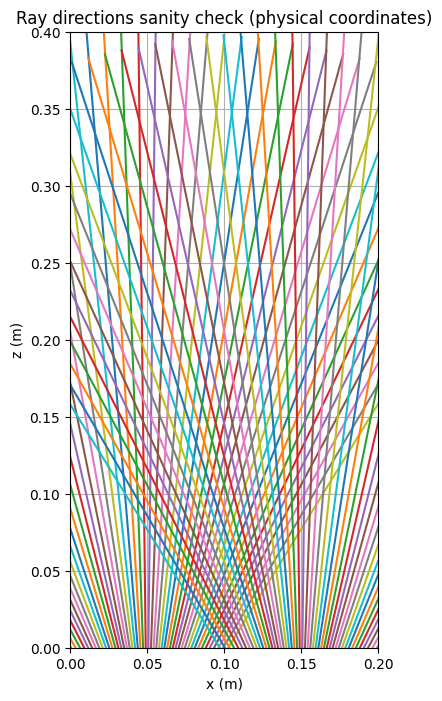

In [12]:
import matplotlib.pyplot as plt
import numpy as np

tank_width = 0.2   # meters
tank_height = 0.4  # meters

plt.figure(figsize=(6, 8))

for i in range(98):  # first 5 rays
    x0 = rays[i, 2]
    z0 = rays[i, 3]
    dx = rays[i, 5]
    dz = rays[i, 6]

    s_vals = np.linspace(0, 0.4, 100)  # slightly longer segment
    x = x0 + s_vals * dx
    z = z0 + s_vals * dz

    plt.plot(x, z)

# 🔹 Set correct physical axes
plt.xlim(0, tank_width)
plt.ylim(0, tank_height)

# 🔹 Equal scaling so angles look correct
plt.gca().set_aspect('equal')

# 🔹 Labels for clarity
plt.xlabel("x (m)")
plt.ylabel("z (m)")

plt.title("Ray directions sanity check (physical coordinates)")
plt.grid(True)

plt.show()

Note:  
- No need to worry about errors caused by being too close to machine precision as our value magnitude range seems to be within $10^{-4}$, which is far from machine precision of $10^{-15}$.

### Stage 2: Ray path 

The next step is to find out the total distance $s$ each ray has travelled, within the container, to do this we need to find the distance $s$ at which the ray exists the container. Rays can exits from one of three boundaries, the left wall, right wall or top wall, depending on the direction of propogation of the ray. This is what this decision function is doing. 

In [13]:
def compute_ray_exit_s(x0, z0, dir_x, dir_z, tank_width, tank_height):
    """
    Returns the first positive s at which the ray exits the tank.
    Tank domain:
        0 <= x <= tank_width
        0 <= z <= tank_height
    Ray:
        x(s) = x0 + s*dir_x
        z(s) = z0 + s*dir_z
    """
    candidates = []

    # left wall: x = 0
    if dir_x < 0: # if the ray is propogating in the left then compute the s value at which it intersects the left container boundary
        s_left = (0.0 - x0) / dir_x
        if s_left > 0:
            candidates.append(s_left)

    # right wall: x = tank_width
    if dir_x > 0: # if the ray is propogating in the right, then compute the s value at which it intersects the right cntainer boundary
        s_right = (tank_width - x0) / dir_x
        if s_right > 0:
            candidates.append(s_right)

    # top wall: z = tank_height
    if dir_z > 0: # if the ray is propogating upwards (and all rays are), then compute the s value at which it intersects the top container boundary
        s_top = (tank_height - z0) / dir_z
        if s_top > 0:
            candidates.append(s_top)

    if not candidates: #sanity check
        raise ValueError(f"No valid exit found for ray starting at ({x0}, {z0})")

    return min(candidates) # return the smallest of the two (top or (left/right)), the larger value is meaningless because the ray would have left the boundary by then

**The next sub step is just appending the exit value for each ray $s_{exit}$ to the ray information table**

In [14]:
def add_s_exit(rays, tank_width, tank_height):
    """
    If s_exit is not present -> append it
    If s_exit exists -> recompute and overwrite the last column
    """

    n_cols = rays.shape[1]

    # Allowed input shapes:
    # original rays before s_exit: 8
    # original rays after s_exit: 9
    # subrays before s_exit: 10
    # subrays after s_exit: 11
    if n_cols not in (8, 9, 10, 11):
        raise ValueError(f"Expected 8, 9, 10, or 11 columns, got {n_cols}")

    s_exit_list = []

    for i in range(rays.shape[0]):
        x0 = rays[i, 2]
        z0 = rays[i, 3]
        dir_x = rays[i, 5]
        dir_z = rays[i, 6]

        s_exit = compute_ray_exit_s(x0, z0, dir_x, dir_z, tank_width, tank_height)
        s_exit_list.append(s_exit)

    s_exit_col = np.array(s_exit_list).reshape(-1, 1)

    # before s_exit exists -> append
    if n_cols in (8, 10):
        return np.hstack([rays, s_exit_col])

    # after s_exit already exists -> overwrite last column
    else:
        rays_copy = rays.copy()
        rays_copy[:, -1] = s_exit_col[:, 0]
        return rays_copy

**The next step is computing how much of each ray $ \Delta s $ is in each cell/pixel**

**Helper functions for computing $\Delta s$**

In [15]:
def compute_all_intersections(x0, z0, dir_x, dir_z, grid, s_exit):
    """
    Compute all s-values where a ray intersects grid lines.
    
    Returns:
        list of s values such that 0 < s < s_exit
    """

    dx = grid["dx"]
    dz = grid["dz"]
    nx = grid["nx"]
    nz = grid["nz"]

    s_values = []

    # Vertical grid lines: x = m * dx 
    if abs(dir_x) > 1e-12:  # avoid division by zero
        for m in range(nx + 1): # for all vertical grid lines, compute s value that intersects that grid line
            x_m = m * dx
            s = (x_m - x0) / dir_x

            if 0 < s < s_exit:
                s_values.append(s)

    # Horizontal grid lines: z = n * dz 
    if abs(dir_z) > 1e-12:
        for n in range(nz + 1): # for all horizontal grid lines, compute s value that intersects that grid line
            z_n = n * dz
            s = (z_n - z0) / dir_z

            if 0 < s < s_exit:
                s_values.append(s)

    return s_values


def build_segments_from_s(x0, z0, dir_x, dir_z, s_values, grid):
    """
    This function takes the sorted s_values which represent a point where the ray intersects a cell boundary, 
    and then finds the difference between consecutive s_values (in the list) to find how much 's' or 'ray' is within a specific
    cell, we use the midpoints to give that 'ray segment' an allocated cell that it belongs too. 

    This tells us how much of this ray is in every cell it crosses

    """

    dx = grid["dx"]
    dz = grid["dz"]
    nx = grid["nx"]
    nz = grid["nz"]

    ray_segments = []

    for k in range(len(s_values) - 1): # for all s_values that intersect a boundry, we compute how much of that ray is within that cell and use the midpoint to label that delta s to a cell
        s_in = s_values[k]
        s_out = s_values[k + 1]
        ds = s_out - s_in

        # midpoint of the segment
        s_mid = 0.5 * (s_in + s_out)
        x_mid = x0 + s_mid * dir_x
        z_mid = z0 + s_mid * dir_z

        # map midpoint to cell index
        i = int(np.floor(x_mid / dx)) #column index
        j = int(np.floor(z_mid / dz)) #row index

        # safety clamp for edge cases near boundaries
        i = min(max(i, 0), nx - 1)
        j = min(max(j, 0), nz - 1)

        ray_segments.append((i, j, s_in, s_out, s_mid, ds))

    return ray_segments

**Defining the main function for finding $\Delta s$**

In [16]:
def compute_ray_segments(rays, grid): # This function goes over all the rays and finds their ray segments in each cell using the helper functions

    all_segments = []

    for r in range(rays.shape[0]): # number of rows (rays)

        x0 = rays[r, 2]
        z0 = rays[r, 3]
        dir_x = rays[r, 5]
        dir_z = rays[r, 6]
        s_exit = rays[r, -1]

        # Step 1: intersections (helper function)
        s_values = compute_all_intersections(x0, z0, dir_x, dir_z, grid, s_exit)

        # Step 2: add endpoints + sort (inline)
        s_values = [0.0] + s_values + [s_exit]
        s_values = sorted(s_values)

        # Step 3: build segments (helper function)
        ray_segments = build_segments_from_s(x0, z0, dir_x, dir_z, s_values, grid)

        all_segments.append(ray_segments)

    return all_segments

**Output of `compute_ray_segments`**

The function returns:

```python
all_segments = [
    ray_0_segments,
    ray_1_segments,
    ray_2_segments,
    ...
]


**and each ray segments looks like this**

```python
ray_i_segments = [
    (i, j, s_mid, delta_s),
    (i, j, s_mid, delta_s),
    ...
]


### Stage 3: Computing subrays

In [17]:
def build_subrays_from_rays(rays, grid, n_subrays=31, subray_spacing_factor=0.25):
    """
    Build parallel subrays around each parent ray.
    """

    if n_subrays % 2 == 0:
        raise ValueError("Use an odd number of subrays (e.g. 5)")

    dx = grid["dx"]
    spacing = subray_spacing_factor * dx

    half = n_subrays // 2
    offsets = np.arange(-half, half + 1) * spacing

    subray_rows = []

    for parent_idx in range(rays.shape[0]):
        laser_id = rays[parent_idx, 0]
        ray_id = rays[parent_idx, 1]

        x_entry = rays[parent_idx, 2]
        z_entry = rays[parent_idx, 3]
        theta_fluid = rays[parent_idx, 4]
        dir_x = rays[parent_idx, 5]
        dir_z = rays[parent_idx, 6]
        r_entry = rays[parent_idx, 7]  

        # perpendicular direction
        n_x = -dir_z
        n_z = dir_x

    
        for subray_id, offset in enumerate(offsets):
            x_sub = x_entry + offset 
            z_sub = z_entry 

            subray_rows.append([
                laser_id,
                ray_id,
                x_sub,
                z_sub,
                theta_fluid,
                dir_x,
                dir_z,
                r_entry,          
                parent_idx,
                subray_id
            ])

    subrays = np.array(subray_rows, dtype=float)

    subrays = np.array(subray_rows, dtype=float)
    subrays = filter_rays_entering_container(subrays, tank_width)

    return subrays

### Using stages 1,2 and 3, we can construct the Geometry function

In [20]:
def geometry(grid, tank_width, tank_height):
    rays = stage1_ray_construction(tank_width)
    rays = add_s_exit(rays, tank_width, tank_height)
    segments = compute_ray_segments(rays, grid)

    subrays = build_subrays_from_rays(rays, grid)
    subrays = add_s_exit(subrays, tank_width, tank_height)
    subray_segments = compute_ray_segments(subrays, grid)

    return {
        "rays": rays, # extra info for sanity checking
        "segments": segments,
        "subrays": subrays,                
        "subray_segments": subray_segments,
        "grid": grid, # extra info for sanity checking
        "tank_width": tank_width, # extra info for sanity checking
        "tank_height": tank_height, # extra info for sanity checking
    }

geom = geometry(grid, Tank_width, Tank_height)

#### CHATGBT sanity check

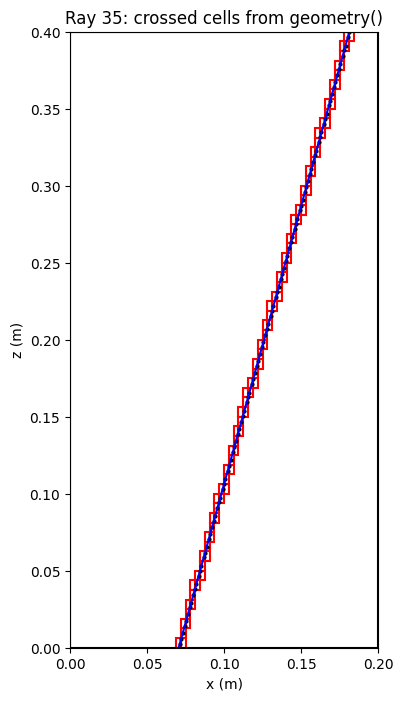

In [21]:
from matplotlib.patches import Rectangle

def plot_ray_segments(geometry, ray_index, tank_width, tank_height):
    rays = geometry["rays"]
    segments = geometry["segments"]
    grid = geometry["grid"]

    dx = grid["dx"]
    dz = grid["dz"]

    x0 = rays[ray_index, 2]
    z0 = rays[ray_index, 3]
    dir_x = rays[ray_index, 5]
    dir_z = rays[ray_index, 6]
    s_exit = rays[ray_index, 8]

    plt.figure(figsize=(6, 8))
    ax = plt.gca()

    # draw crossed cells
    for (i, j, s_in, s_out, s_mid, ds) in segments[ray_index]:
        rect = Rectangle((i * dx, j * dz), dx, dz,
                         fill=False, edgecolor='red', linewidth=1.5)
        ax.add_patch(rect)

        # optional: mark midpoint of the segment
        x_mid = x0 + s_mid * dir_x
        z_mid = z0 + s_mid * dir_z
        plt.plot(x_mid, z_mid, 'ko', markersize=2)

    # draw full ray
    s_vals = np.linspace(0, s_exit, 200)
    x = x0 + s_vals * dir_x
    z = z0 + s_vals * dir_z
    plt.plot(x, z, 'b-')

    # tank boundary
    plt.plot([0, tank_width, tank_width, 0, 0],
             [0, 0, tank_height, tank_height, 0],
             'k-', linewidth=1.5)

    plt.xlim(0, tank_width)
    plt.ylim(0, tank_height)
    plt.gca().set_aspect('equal')
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(f"Ray {ray_index}: crossed cells from geometry()")
    plt.show()

plot_ray_segments(geom, 35,Tank_width, Tank_height)

## Part 2: Defining the Optical Part 

Stage 1 of the optical part is Illuminating the cells with the light from the rays adjusting for inverse/spreading law.

(later show the structire of what Optical model should look like)

### Stage 1: Illumination/Spreading & Flourescence 

**Proper implementation (including lambert beer attenuation)**

In [22]:
# helper function
import torch

def lambert_beer_step_torch(I_in, concentration, ds, epsilon):
    tau = epsilon * concentration * ds
    I_out = I_in * torch.exp(-tau)
    dI = I_in - I_out
    return I_out, dI

In [23]:
def compute_dye_fluorescence_torch(state, geometry, epsilon, beta=1.0, I0=1.0, eps=1e-12):
    """
    Torch version of fluorescence forward model.
    Differentiable with respect to `state`.
    """

    # choose rays or subrays
    if "subrays" in geometry and "subray_segments" in geometry:
        rays = geometry["subrays"]
        segments = geometry["subray_segments"]
    else:
        rays = geometry["rays"]
        segments = geometry["segments"]

    grid = geometry["grid"]
    nx = grid["nx"]
    nz = grid["nz"]

    device = state.device
    dtype = state.dtype

    fluorescence_map = torch.zeros((nz, nx), dtype=dtype, device=device)

    # geometry stays fixed; okay to process with numpy/python
    laser_ids = rays[:, 0].astype(int)
    unique_lasers, counts = np.unique(laser_ids, return_counts=True)
    rays_per_laser = {lid: c for lid, c in zip(unique_lasers, counts)}

    for ray_index, ray_segments in enumerate(segments):
        laser_id = int(rays[ray_index, 0])
        r_entry = float(rays[ray_index, 7])

        w_k = 1.0 / rays_per_laser[laser_id]

        # make torch scalar
        I_current = torch.tensor(
            (w_k * I0) / max(r_entry, eps),
            dtype=dtype,
            device=device
        )

        for (i, j, s_in, s_out, s_mid, ds) in ray_segments:
            concentration = state[j, i]

            ds_t = torch.tensor(ds, dtype=dtype, device=device)

            I_out, dI = lambert_beer_step_torch(I_current, concentration, ds_t, epsilon)

            fluorescence_map[j, i] = fluorescence_map[j, i] + beta * dI

            r_in = float(r_entry + s_in)
            r_out = float(r_entry + s_out)

            spread_ratio = max(r_in, eps) / max(r_out, eps)
            spread_ratio_t = torch.tensor(spread_ratio, dtype=dtype, device=device)

            I_current = I_out * spread_ratio_t

    return fluorescence_map

In [24]:
def plot_fluorescence_map(result, geometry, tank_width, tank_height):
    fluorescence_map = result
    grid = geometry["grid"]

    nx = grid["nx"]
    nz = grid["nz"]
    dx = grid["dx"]
    dz = grid["dz"]

    plt.figure(figsize=(6, 8))
    plt.imshow(
        fluorescence_map,
        origin="lower",
        extent=[0, tank_width, 0, tank_height],
        aspect="equal",
        cmap="inferno"   # better contrast for fluorescence
    )
    plt.colorbar(label="Fluorescence")

    # draw grid lines
    for m in range(nx + 1):
        x = m * dx
        plt.plot([x, x], [0, tank_height], color="white", linewidth=0.3, alpha=0.4)

    for n in range(nz + 1):
        z = n * dz
        plt.plot([0, tank_width], [z, z], color="white", linewidth=0.3, alpha=0.4)

    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title("Cellwise Fluorescence Map")
    plt.show()


**Helper function for removing ray accumulation at boundaries which is a numerical issue**

In [37]:
def remove_boundary_artifacts_torch(fmap, n_boundary=1):
    """
    Zero out a fixed number of boundary pixels on each side.
    Differentiable w.r.t. fmap because the mask is constant.
    """
    mask = torch.ones_like(fmap)

    if n_boundary > 0:
        # top boundary (highest z)
        mask[-n_boundary:, :] = 0

        # left boundary
        mask[:, :n_boundary] = 0

        # right boundary
        mask[:, -n_boundary:] = 0

    return fmap * mask

### Blurring Image Kernal (Gaussian blur)

In [26]:
import torch.nn.functional as F


def apply_camera_blur_torch(fluorescence_map, sigma_px=1.0, kernel_size=9):
    if sigma_px <= 0:
        return fluorescence_map.clone()

    device = fluorescence_map.device
    dtype = fluorescence_map.dtype

    coords = torch.arange(kernel_size, device=device, dtype=dtype) - kernel_size // 2
    yy, xx = torch.meshgrid(coords, coords, indexing="ij")

    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma_px**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.view(1, 1, kernel_size, kernel_size)

    fmap_4d = fluorescence_map.unsqueeze(0).unsqueeze(0)

    pad = kernel_size // 2
    fmap_padded = F.pad(fmap_4d, (pad, pad, pad, pad), mode="replicate")

    blurred_4d = F.conv2d(fmap_padded, kernel)
    return blurred_4d.squeeze(0).squeeze(0)



### Building Final Optical Model Function (A_torch is what you want to import)

In [27]:
# for 1d flattened image
def A_torch(state, geometry):
    fm = compute_dye_fluorescence_torch(state, geometry, epsilon=1.0, beta=1.0, I0=1.0)
    fm_clean = remove_boundary_artifacts_torch(fm, n_boundary=1)
    fm_blurred = apply_camera_blur_torch(fm_clean, sigma_px=1.0)
    b = fm_blurred.reshape(-1)
    return b

# for original 2d image (for plotting/visualizing)
def A_image_torch(state, geometry):
    fm = compute_dye_fluorescence_torch(state, geometry, epsilon=1.0, beta=1.0, I0=1.0)
    fm_clean = remove_boundary_artifacts_torch(fm)
    fm_blurred = apply_camera_blur_torch(fm_clean, sigma_px=1.0)
    return fm_blurred



In [41]:
# geometry
geom = geometry(grid, Tank_width, Tank_height)

# grid info
grid = geom["grid"]
nx = grid["nx"]
nz = grid["nz"]

# true state
state_true = np.ones((nz, nx)) * 0.5
state_true_t = torch.tensor(state_true, dtype=torch.float32)

# observed image from true state
b_obs = A_torch(state_true_t, geom).detach()

# initial guess = slightly perturbed version
state_guess = state_true + 0.2 * np.random.randn(nz, nx)
state_guess = np.clip(state_guess, 0.0, 1.0)
state_guess_t = torch.tensor(state_guess, dtype=torch.float32, requires_grad=True)

# predicted image from guess
b_pred = A_torch(state_guess_t, geom)

# loss
loss = torch.mean((b_pred - b_obs)**2)

if state_guess_t.grad is not None:
    state_guess_t.grad.zero_()

loss.backward()

print("loss:", loss.item())
print("grad exists:", state_guess_t.grad is not None)
print("grad shape:", state_guess_t.grad.shape)
print("max abs grad:", state_guess_t.grad.abs().max().item())
print("any NaNs:", torch.isnan(state_guess_t.grad).any().item())

loss: 3.7609049208242595e-09
grad exists: True
grad shape: torch.Size([64, 64])
max abs grad: 9.345595408660756e-10
any NaNs: False


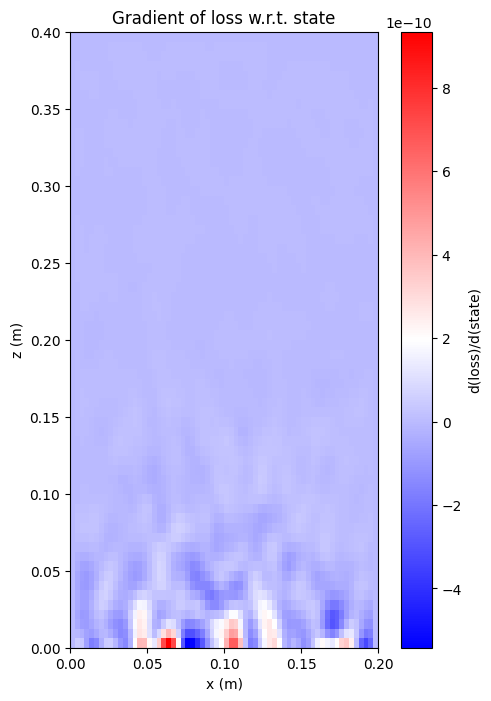

old loss: 3.7609049208242595e-09
new loss: 3.749553556531282e-09


In [ ]:
grad_np = state_guess_t.grad.detach().cpu().numpy()

plt.figure(figsize=(6, 8))
plt.imshow(
    grad_np,
    origin="lower",
    extent=[0, Tank_width, 0, Tank_height],
    aspect="equal",
    cmap="bwr"
)
plt.colorbar(label="d(loss)/d(state)")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Gradient of loss w.r.t. state")
plt.show()

with torch.no_grad():
    alpha = 1e6  # may need tuning
    state_new = state_guess_t - alpha * state_guess_t.grad
    state_new = torch.clamp(state_new, 0.0, 1.0)

b_new = A_torch(state_new, geom)
loss_new = torch.mean((b_new - b_obs)**2)

print("old loss:", loss.item())
print("new loss:", loss_new.item())

**Testing dye concentrations**

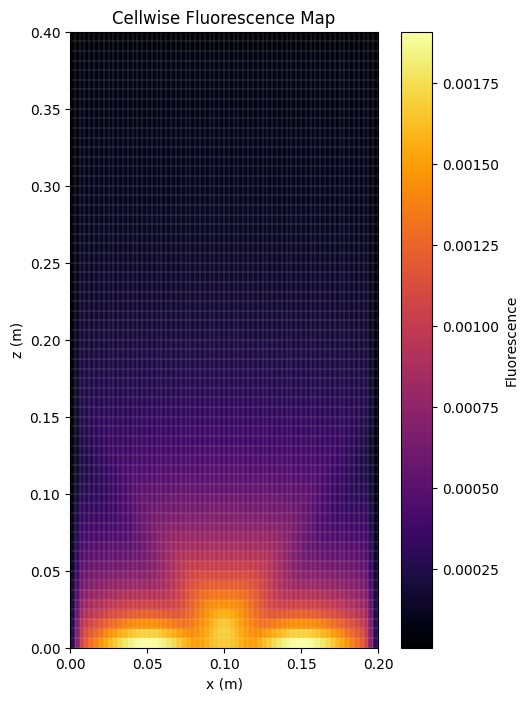

In [45]:
#define geometry
geom = geometry(grid, Tank_width, Tank_height)

#define state
grid = geom["grid"]
nx = grid["nx"]
nz = grid["nz"]

state = np.ones((nz, nx)) * 0.5   # uniform concentration (0–1)
state_t = torch.tensor(state, dtype=torch.float32)

# run model
b_image = A_image_torch(state_t, geom)

# plot
plot_fluorescence_map(
    b_image.detach().cpu().numpy(),
    geometry=geom,
    tank_width=Tank_width,
    tank_height=Tank_height
)

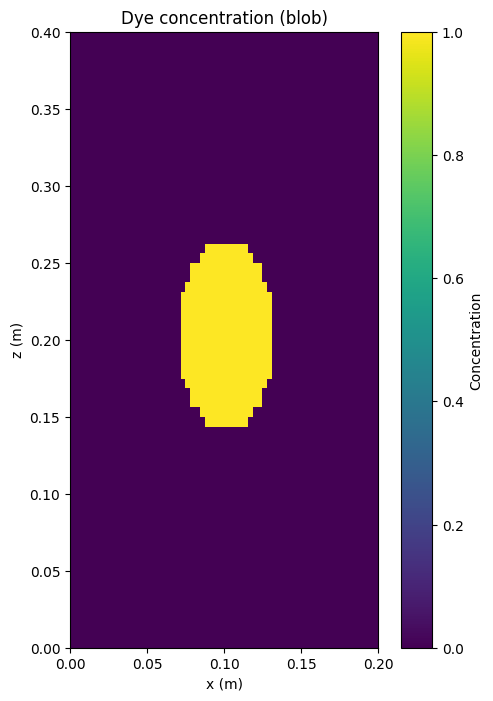

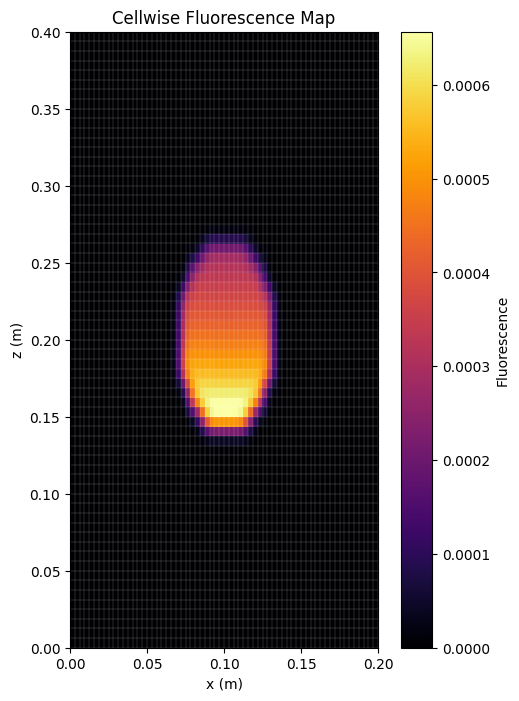

In [40]:
state = np.zeros((nz, nx))

# center blob
cx, cz = nx // 2, nz // 2
radius = min(nx, nz) // 6

for j in range(nz):
    for i in range(nx):
        if (i - cx)**2 + (j - cz)**2 < radius**2:
            state[j, i] = 1.0

# plotting dye concentration blob 
plt.figure(figsize=(6, 8))
plt.imshow(
    state,
    origin="lower",
    extent=[0, Tank_width, 0, Tank_height],
    aspect="equal",
    cmap="viridis"
)
plt.colorbar(label="Concentration")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Dye concentration (blob)")
plt.show()

#covert state to tensor
state_t = torch.tensor(state, dtype=torch.float32)
b_image = A_image_torch(state_t, geom)
    
# plot
plot_fluorescence_map(
    b_image.detach().cpu().numpy(),
    geometry=geom,
    tank_width=Tank_width,
    tank_height=Tank_height
)


### What $A(\text{state}, \text{geometry})$ does visualized:

$$
\begin{bmatrix}
I_{1,1} & I_{1,2} & \cdots & I_{1,n_x} \\
I_{2,1} & I_{2,2} & \cdots & I_{2,n_x} \\
\vdots  & \vdots  & \ddots & \vdots \\
I_{n_z,1} & I_{n_z,2} & \cdots & I_{n_z,n_x}
\end{bmatrix}
\;\;\longrightarrow\;\;
\begin{bmatrix}
\tilde{I}_{1,1} & \tilde{I}_{1,2} & \cdots & \tilde{I}_{1,n_x} \\
\tilde{I}_{2,1} & \tilde{I}_{2,2} & \cdots & \tilde{I}_{2,n_x} \\
\vdots  & \vdots  & \ddots & \vdots \\
\tilde{I}_{n_z,1} & \tilde{I}_{n_z,2} & \cdots & \tilde{I}_{n_z,n_x}
\end{bmatrix}
\;\;\longrightarrow\;\;
\begin{bmatrix}
\tilde{I}_{1,1} \\
\tilde{I}_{1,2} \\
\vdots \\
\tilde{I}_{n_z,n_x}
\end{bmatrix}
$$

$$
\text{Fluorescence map} \qquad\qquad
\text{Blurred fluorescence map} \qquad\qquad\quad
\text{Flattened image}
$$